## Primer dataset

In [ ]:
# Entrenando un modelo a partir de un dataset
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="dataset/supermercado/data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    device=0
)


New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None,

In [ ]:
# Realizar predicción sobre una imagen específica
img_path = 'dataset/supermercado/valid/images'
resultados = model(img_path)

# Mostrar la cantidad bruta de detecciones
print(f"Objetos detectados inicialmente: {len(resultados[0].boxes)}")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1078 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/valid/images/test_0_jpg.rf.f7ba5c621d9674cf5c274dec918f310a.jpg: 640x480 145 objects, 56.8ms
image 2/1078 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/valid/images/test_101_jpg.rf.a96544c15b8e306637567e49169b1d0b.jpg: 640x384 124 objects, 62.4ms
image 3/1078 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/v

In [ ]:
from collections import Counter

# 1. Umbral de confianza
UMBRAL_CONF = 0.4  # Solo aceptamos detecciones con >40% de seguridad

# 2. Extraer cajas de la predicción
prediccion = resultados[0]
cajas_totales = prediccion.boxes

# 3. Filtrar por confianza (box.conf suele ser tensor -> conviértelo a float)
boxes_filtradas = [box for box in cajas_totales if float(box.conf) > UMBRAL_CONF]

print(f"Objetos reales tras filtrar (Confianza > {UMBRAL_CONF}): {len(boxes_filtradas)}")

# 4. Conteo por clase
ids_clases = [int(box.cls) for box in boxes_filtradas]
conteos = Counter(ids_clases)

print("\nREPORTE DE INVENTARIO:")
nombres_clases = model.names

for clase_id, cantidad in conteos.items():
    nombre_obj = nombres_clases[clase_id]
    print(f" -> {nombre_obj}: {cantidad} unidades")


Objetos reales tras filtrar (Confianza > 0.4): 142

REPORTE DE INVENTARIO:
 -> object: 142 unidades


pred.plot() -> <class 'numpy.ndarray'>
img_resultado shape/dtype: (2048, 1536, 3) uint8


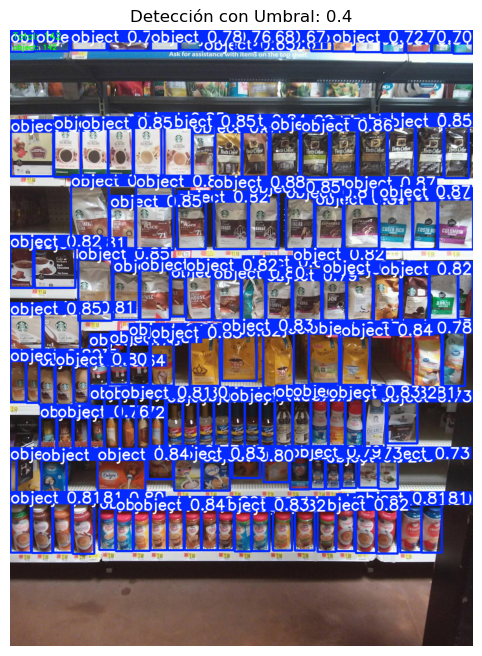

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualizar_conteo(pred, boxes_filtradas, conteos, umbral):
 # 1. Filtrado visual
    pred.boxes = pred.boxes[pred.boxes.conf > umbral]

    # 2. Render de la predicción
    img_resultado = pred.plot()
    print("pred.plot() ->", type(img_resultado))

    if img_resultado is None:
        raise ValueError("pred.plot() devolvió None. Revisa que 'prediccion' sea resultados[0] válido.")

    img_resultado = np.asarray(img_resultado)
    print("img_resultado shape/dtype:", img_resultado.shape, img_resultado.dtype)

    # 3. Texto por clase
    nombres = pred.names
    texto_conteo = ", ".join([f"{nombres[c]}: {n}" for c, n in conteos.items()])

    # 4. Pintar texto
    cv2.putText(img_resultado, f"Total: {len(boxes_filtradas)}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    if texto_conteo:
        cv2.putText(img_resultado, texto_conteo, (10, 65),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # 5. BGR -> RGB (necesario para Matplotlib)
    img_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)

    # 6. Mostrar
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Detección con Umbral: {umbral}")
    plt.show()

# Llamando a la función
visualizar_conteo(resultados[0], boxes_filtradas, conteos, UMBRAL_CONF)

### Función analizar_estanteria


image 1/1 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/supermercado/test/images/test_1051_jpg.rf.8f81f58653cbb0e91ca0e6021077b297.jpg: 640x480 142 objects, 7.5ms
Speed: 12.6ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
pred.plot() -> <class 'numpy.ndarray'>
img_resultado shape/dtype: (2048, 1536, 3) uint8


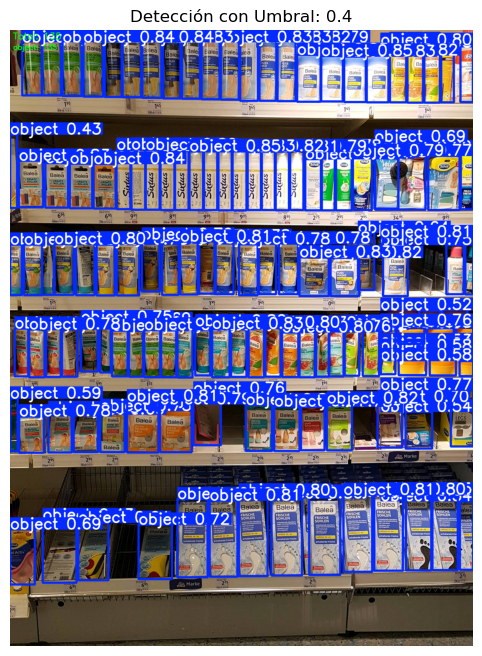

Imagen: dataset/supermercado/test/images/test_1051_jpg.rf.8f81f58653cbb0e91ca0e6021077b297.jpg
Total productos (conf > 0.4): 135
 - object: 135
------------------------------------------------------------

image 1/1 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/supermercado/test/images/test_1061_jpg.rf.166359607508fe391350e1628c8e02db.jpg: 640x480 135 objects, 5.1ms
Speed: 1.4ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
pred.plot() -> <class 'numpy.ndarray'>
img_resultado shape/dtype: (2048, 1536, 3) uint8


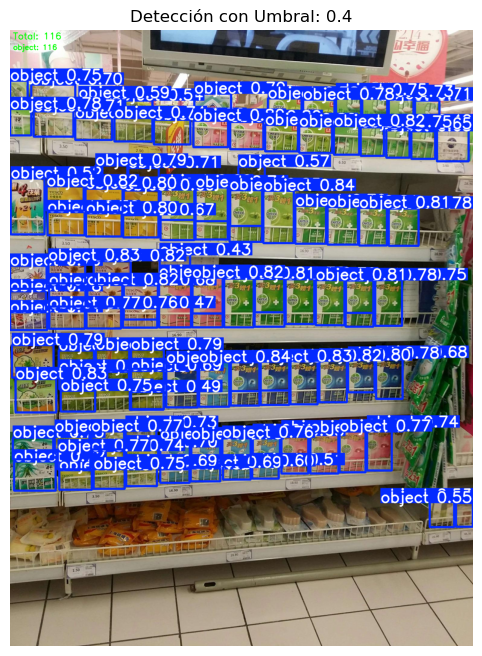

Imagen: dataset/supermercado/test/images/test_1061_jpg.rf.166359607508fe391350e1628c8e02db.jpg
Total productos (conf > 0.4): 116
 - object: 116
------------------------------------------------------------

image 1/1 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/supermercado/test/images/test_1080_jpg.rf.021ed8dfa207e233a31187fa72727979.jpg: 640x480 144 objects, 4.8ms
Speed: 1.3ms preprocess, 4.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
pred.plot() -> <class 'numpy.ndarray'>
img_resultado shape/dtype: (2048, 1536, 3) uint8


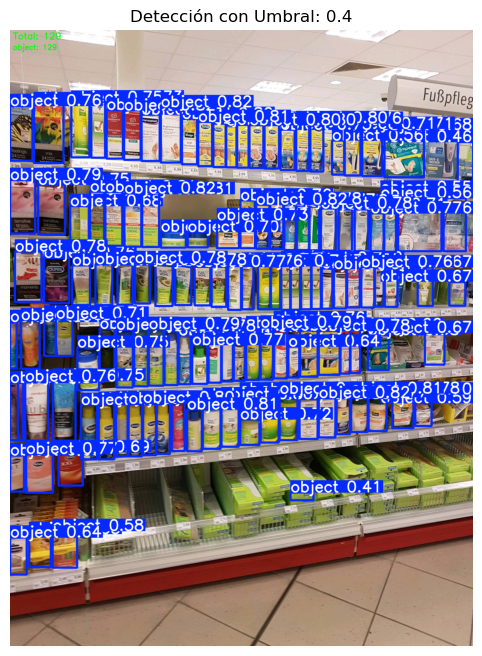

Imagen: dataset/supermercado/test/images/test_1080_jpg.rf.021ed8dfa207e233a31187fa72727979.jpg
Total productos (conf > 0.4): 129
 - object: 129
------------------------------------------------------------

image 1/1 /home/ciabd10/Descargas/Modelos-Inteligencia-Artificial/Actividad_6/dataset/supermercado/test/images/test_1051_jpg.rf.8f81f58653cbb0e91ca0e6021077b297.jpg: 640x480 142 objects, 5.1ms
Speed: 1.4ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
pred.plot() -> <class 'numpy.ndarray'>
img_resultado shape/dtype: (2048, 1536, 3) uint8


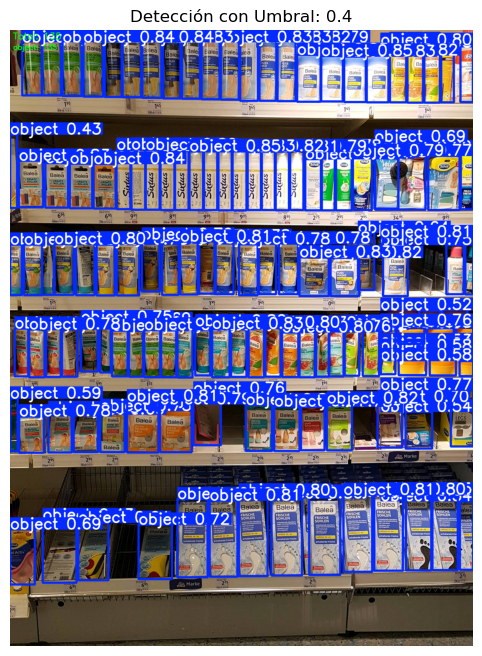

(135, Counter({0: 135}))

In [ ]:
import glob
from collections import Counter

def analizar_estanteria(ruta_imagen, model, umbral=0.4, visualizar=False):
    # 1) Inferencia
    resultados = model(ruta_imagen)
    pred = resultados[0]
    
    # 2) Filtrado por confianza
    cajas = pred.boxes
    boxes_filtradas = [b for b in cajas if float(b.conf) > umbral]
    
    # 3) Conteo (por clase)
    ids_clases = [int(b.cls) for b in boxes_filtradas]
    conteos = Counter(ids_clases)
    total = len(boxes_filtradas)

# --- Listar test + ejecutar primeras 3 ---
test_images_glob = "dataset/supermercado/test/images/*.jpg"


rutas_test = sorted(glob.glob(test_images_glob))

for ruta in rutas_test[:3]:
    total, conteos = analizar_estanteria(ruta, model, umbral=UMBRAL_CONF, visualizar=True)
    print(f"Imagen: {ruta}")
    print(f"Total productos (conf > {UMBRAL_CONF}): {total}")
    # Si quieres, imprime el detalle por clase:
    for clase_id, n in conteos.items():
        print(f" - {model.names[clase_id]}: {n}")
    print("-"*60)

# Llamando a la función
analizar_estanteria(rutas_test[0], model, umbral=UMBRAL_CONF, visualizar=True)


# PARTE 2 - DETECCIÓN DE SEÑALES DE TRÁFICO

### Para la segunda parte entrenamos un modelo con un dataset distinto para identificar objetos de diferentes tipos
En este caso usamos un dataset de señales de tráfico de Roboflow para detectar distintos tipos de señales viales.

In [42]:
from ultralytics import YOLO

# Entrenar modelo con dataset de Roboflow
modelo_señales_2 = YOLO("yolo11n.pt")

# Cambiar la ruta según donde descargaste el dataset de Roboflow
results = modelo_señales_2.train(
    data="dataset/señales/data.yaml",  # ← Ajusta si es diferente
    epochs=25,
    imgsz=640,
    batch=16,
    device=0
)


New https://pypi.org/project/ultralytics/8.4.12 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/señales/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, op

In [20]:
from ultralytics import YOLO
import os
import glob
import gc

# Cargar el mejor modelo entrenado (user-provided path)
weights_candidate = 'runs/detect/train7/weights/best.pt'
if not os.path.exists(weights_candidate):
    # Buscar último entrenamiento disponible
    train_dirs = sorted([d for d in glob.glob('runs/detect/train*') if os.path.isdir(d)])
    if not train_dirs:
        raise FileNotFoundError('No se encontraron pesos entrenados en runs/detect/*/weights/best.pt')
    weights_candidate = f"{train_dirs[-1]}/weights/best.pt"

print(f"✓ Cargando pesos desde: {weights_candidate}")
modelo_señales = YOLO(weights_candidate)
print(f"✓ Modelo cargado. {len(modelo_señales.names)} clases disponibles")
# Forzar garbage collection por si quedó memoria de pasos previos
gc.collect()

✓ Cargando pesos desde: runs/detect/train7/weights/best.pt
✓ Modelo cargado. 55 clases disponibles


6928

In [21]:
import glob
import os
from pathlib import Path

# RUTA a la carpeta de imágenes (no pasar la carpeta entera al modelo en una sola llamada)
RUTA_IMAGENES = 'dataset/señales/valid/images'

# Comprobar alternativas si no existe la ruta
if not os.path.exists(RUTA_IMAGENES):
    alt_candidates = [
        'dataset/traffic-signs-detection-europe/valid/images',
        'dataset/traffic-signs-detection-europe/test/images',
        'dataset/señales/test/images'
    ]
    for alt in alt_candidates:
        if os.path.exists(alt):
            RUTA_IMAGENES = alt
            print(f"Usando carpeta alternativa: {alt}")
            break

# Obtener lista de archivos (no los cargamos todos en memoria)
image_files = sorted(glob.glob(os.path.join(RUTA_IMAGENES, '*.jpg')) + glob.glob(os.path.join(RUTA_IMAGENES, '*.png')))
if not image_files:
    raise FileNotFoundError(f"No se encontraron imágenes en {RUTA_IMAGENES}")

print(f"✓ Encontradas {len(image_files)} imágenes en: {RUTA_IMAGENES}")
print("Procesaremos las primeras 3 imágenes de manera individual para evitar consumo excesivo de memoria.")

# Nota: no llamamos a modelo_señales(RUTA_IMAGENES) (eso cargaría todas las imágenes a la vez).
# En su lugar llamaremos a modelo_señales por cada ruta de imagen en el bucle de inferencia.

# Guardar iterator o lista a usar en la siguiente celda
archivos_para_procesar = image_files[:3]  # cambiar el número si quieres más/menos

✓ Encontradas 1128 imágenes en: dataset/señales/valid/images
Procesaremos las primeras 3 imágenes de manera individual para evitar consumo excesivo de memoria.


🚦 REPORTE DE SEÑALES POR IMAGEN (procesando uno a uno)

📸 Procesando: AUTO_COLLECTED_PICTURE_0_png.rf.3aa566303b61b1f71bb70abeb0561c65.jpg
Objetos detectados (Conf > 0.4): 1
 -> mand_straight: 1


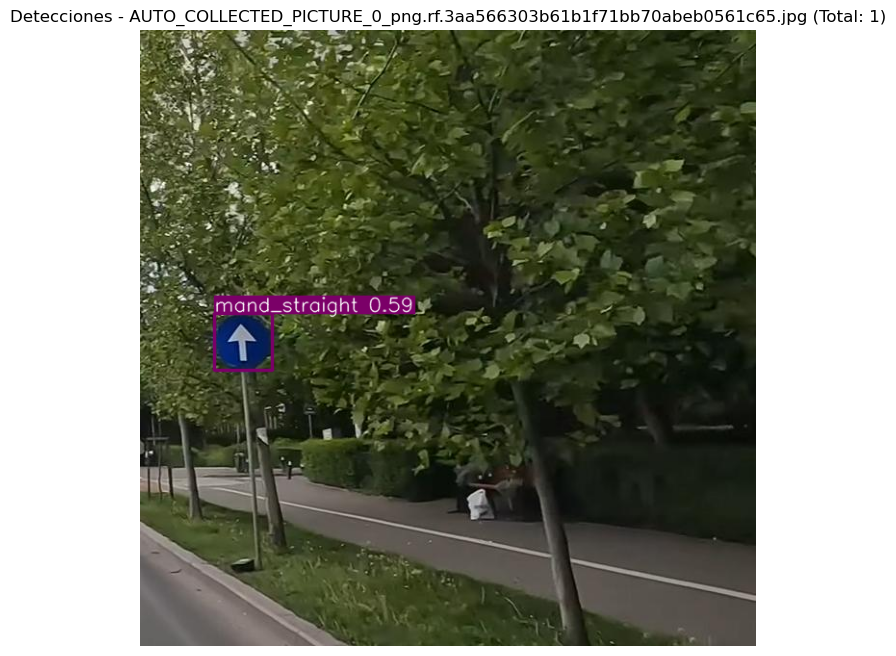


📸 Procesando: AUTO_COLLECTED_PICTURE_104_png.rf.f1d63948496e43aa84b28972b5ed9765.jpg
Objetos detectados (Conf > 0.4): 1
 -> info_parking: 1


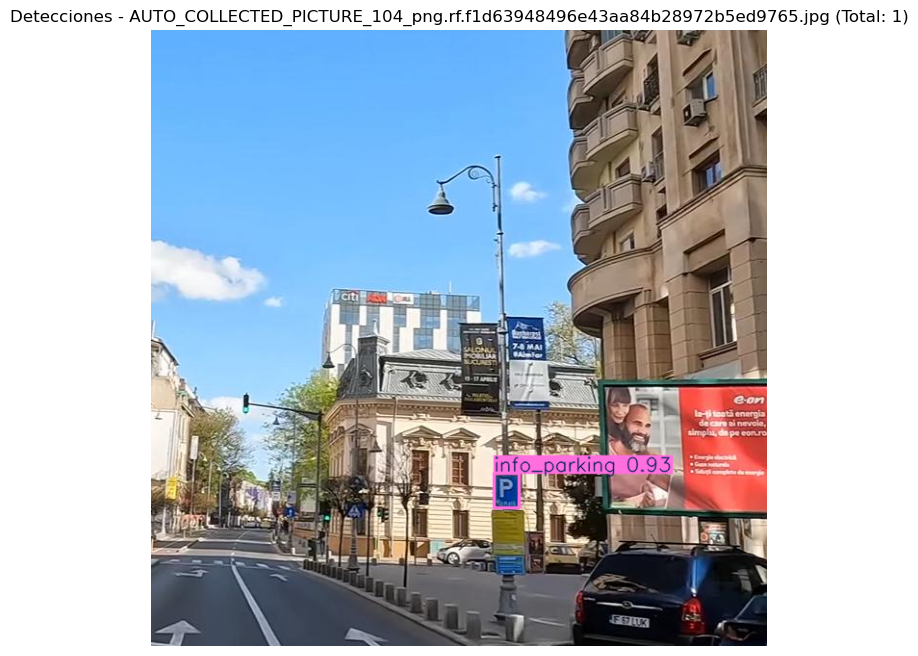


📸 Procesando: AUTO_COLLECTED_PICTURE_106_png.rf.3b96ef64a5d76fe20a53d2bbd000d91b.jpg
Objetos detectados (Conf > 0.4): 2
 -> info_crosswalk: 1
 -> mand_straight_right: 1
Objetos detectados (Conf > 0.4): 2
 -> info_crosswalk: 1
 -> mand_straight_right: 1


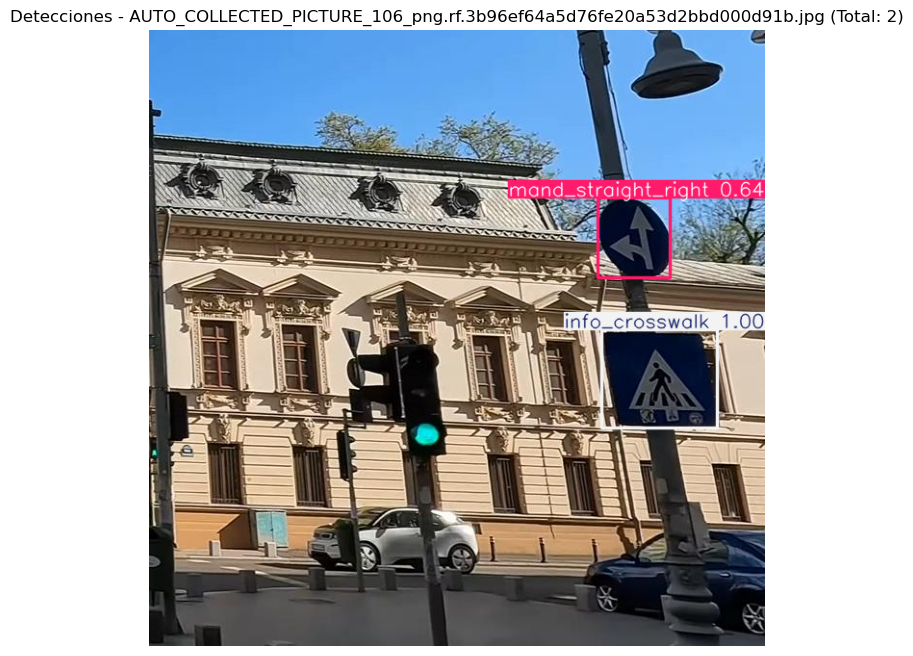


🚦 REPORTE GLOBAL DEL DATASET
Total objetos detectados (suma): 4
 -> mand_straight: 1
 -> info_parking: 1
 -> info_crosswalk: 1
 -> mand_straight_right: 1

✓ Procesado completado (sin retrain).


In [22]:
from collections import Counter
import numpy as np
import cv2
import matplotlib.pyplot as plt
import gc

# Umbral de confianza para mostrar y contar
UMBRAL_CONF = 0.4
conteos_globales = Counter()

print("🚦 REPORTE DE SEÑALES POR IMAGEN (procesando uno a uno)")

for ruta in archivos_para_procesar:
    print(f"\n📸 Procesando: {Path(ruta).name}")

    # Inferencia por archivo (evita cargar todas las imágenes a la vez)
    results = modelo_señales(ruta, conf=0.01, verbose=False)
    pred = results[0]

    # Filtrar por confianza
    boxes_filtradas = [b for b in pred.boxes if float(b.conf) > UMBRAL_CONF]

    print(f"Objetos detectados (Conf > {UMBRAL_CONF}): {len(boxes_filtradas)}")

    # Conteo por clase en la imagen
    ids_clases = [int(b.cls) for b in boxes_filtradas]
    conteos = Counter(ids_clases)

    if conteos:
        for clase_id, cantidad in conteos.items():
            nombre = pred.names.get(clase_id, f"Clase {clase_id}")
            print(f" -> {nombre}: {cantidad}")

    # Acumular en conteo global
    conteos_globales.update(ids_clases)

    # Visualización: dejar que pred.plot() dibuje solo las cajas filtradas
    pred.boxes = pred.boxes[pred.boxes.conf > UMBRAL_CONF]
    img_annotada = pred.plot()

    if img_annotada is not None:
        img_np = np.asarray(img_annotada)
        if img_np.ndim == 3 and img_np.shape[2] == 3:
            img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = img_np

        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"Detecciones - {Path(ruta).name} (Total: {len(boxes_filtradas)})")
        plt.show()
    else:
        print("⚠️ No se pudo generar la imagen anotada para esta imagen")

    # Liberar memoria explícitamente
    del results, pred, boxes_filtradas, ids_clases, conteos, img_np, img_rgb
    gc.collect()

# Reporte global
print("\n🚦 REPORTE GLOBAL DEL DATASET")
print(f"Total objetos detectados (suma): {sum(conteos_globales.values())}")
for clase_id, cantidad in conteos_globales.items():
    nombre = modelo_señales.names.get(clase_id, f"Clase {clase_id}")
    print(f" -> {nombre}: {cantidad}")

print("\n✓ Procesado completado (sin retrain).")

## Matriz de Confusión y Métricas del Entrenamiento

MÉTRICAS Y VISUALIZACIONES DEL ENTRENAMIENTO

✓ Carpeta: runs/detect/train7

✅ Gráficos de entrenamiento:


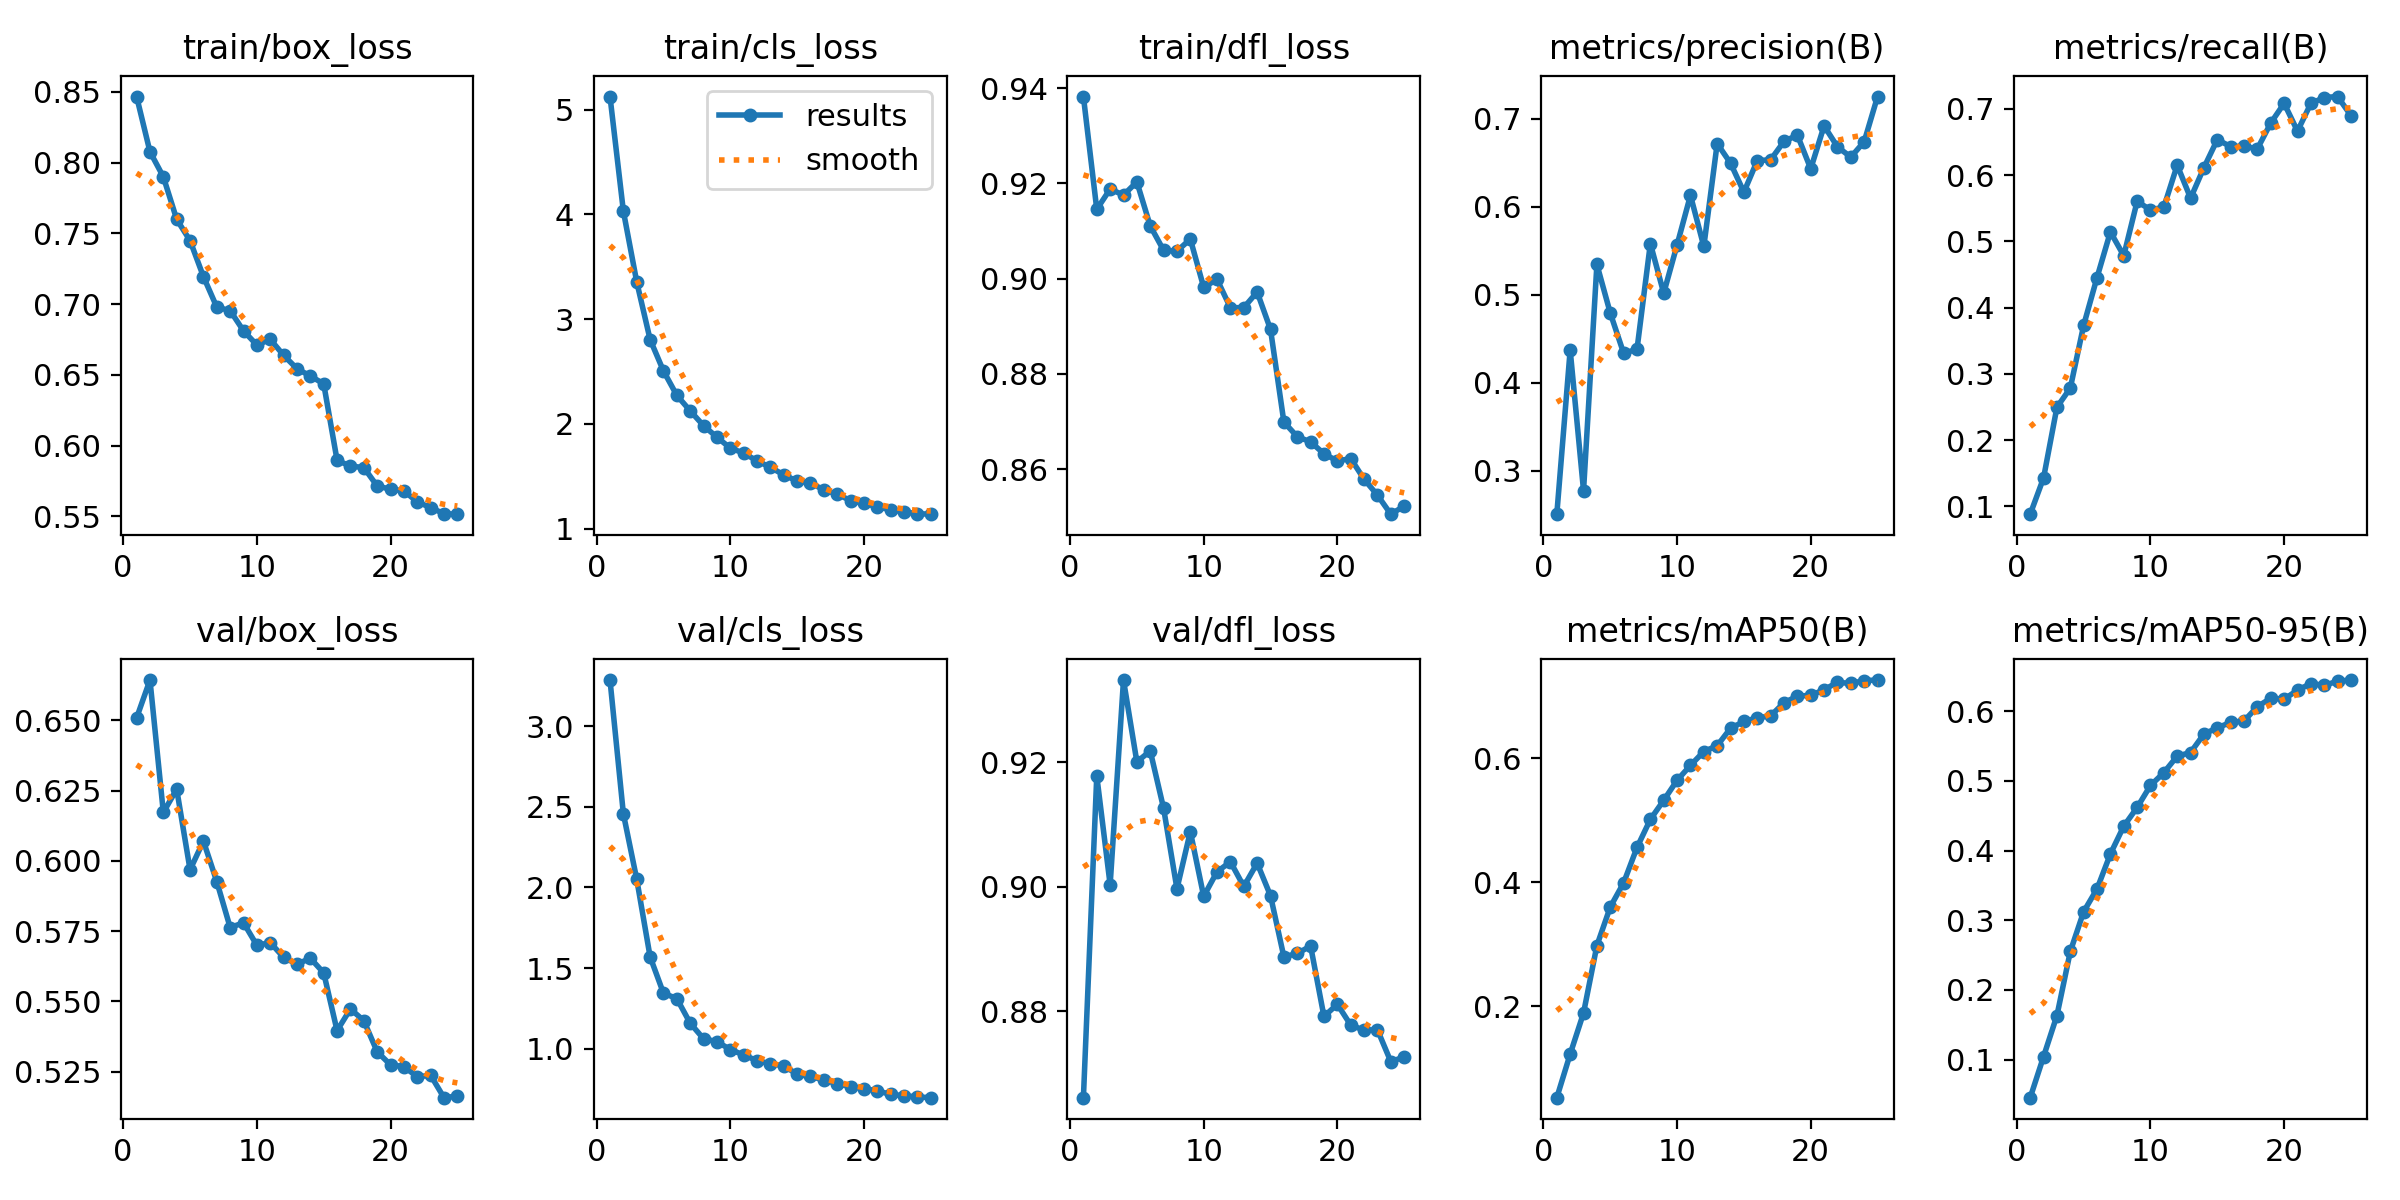


✅ Matriz de confusión:


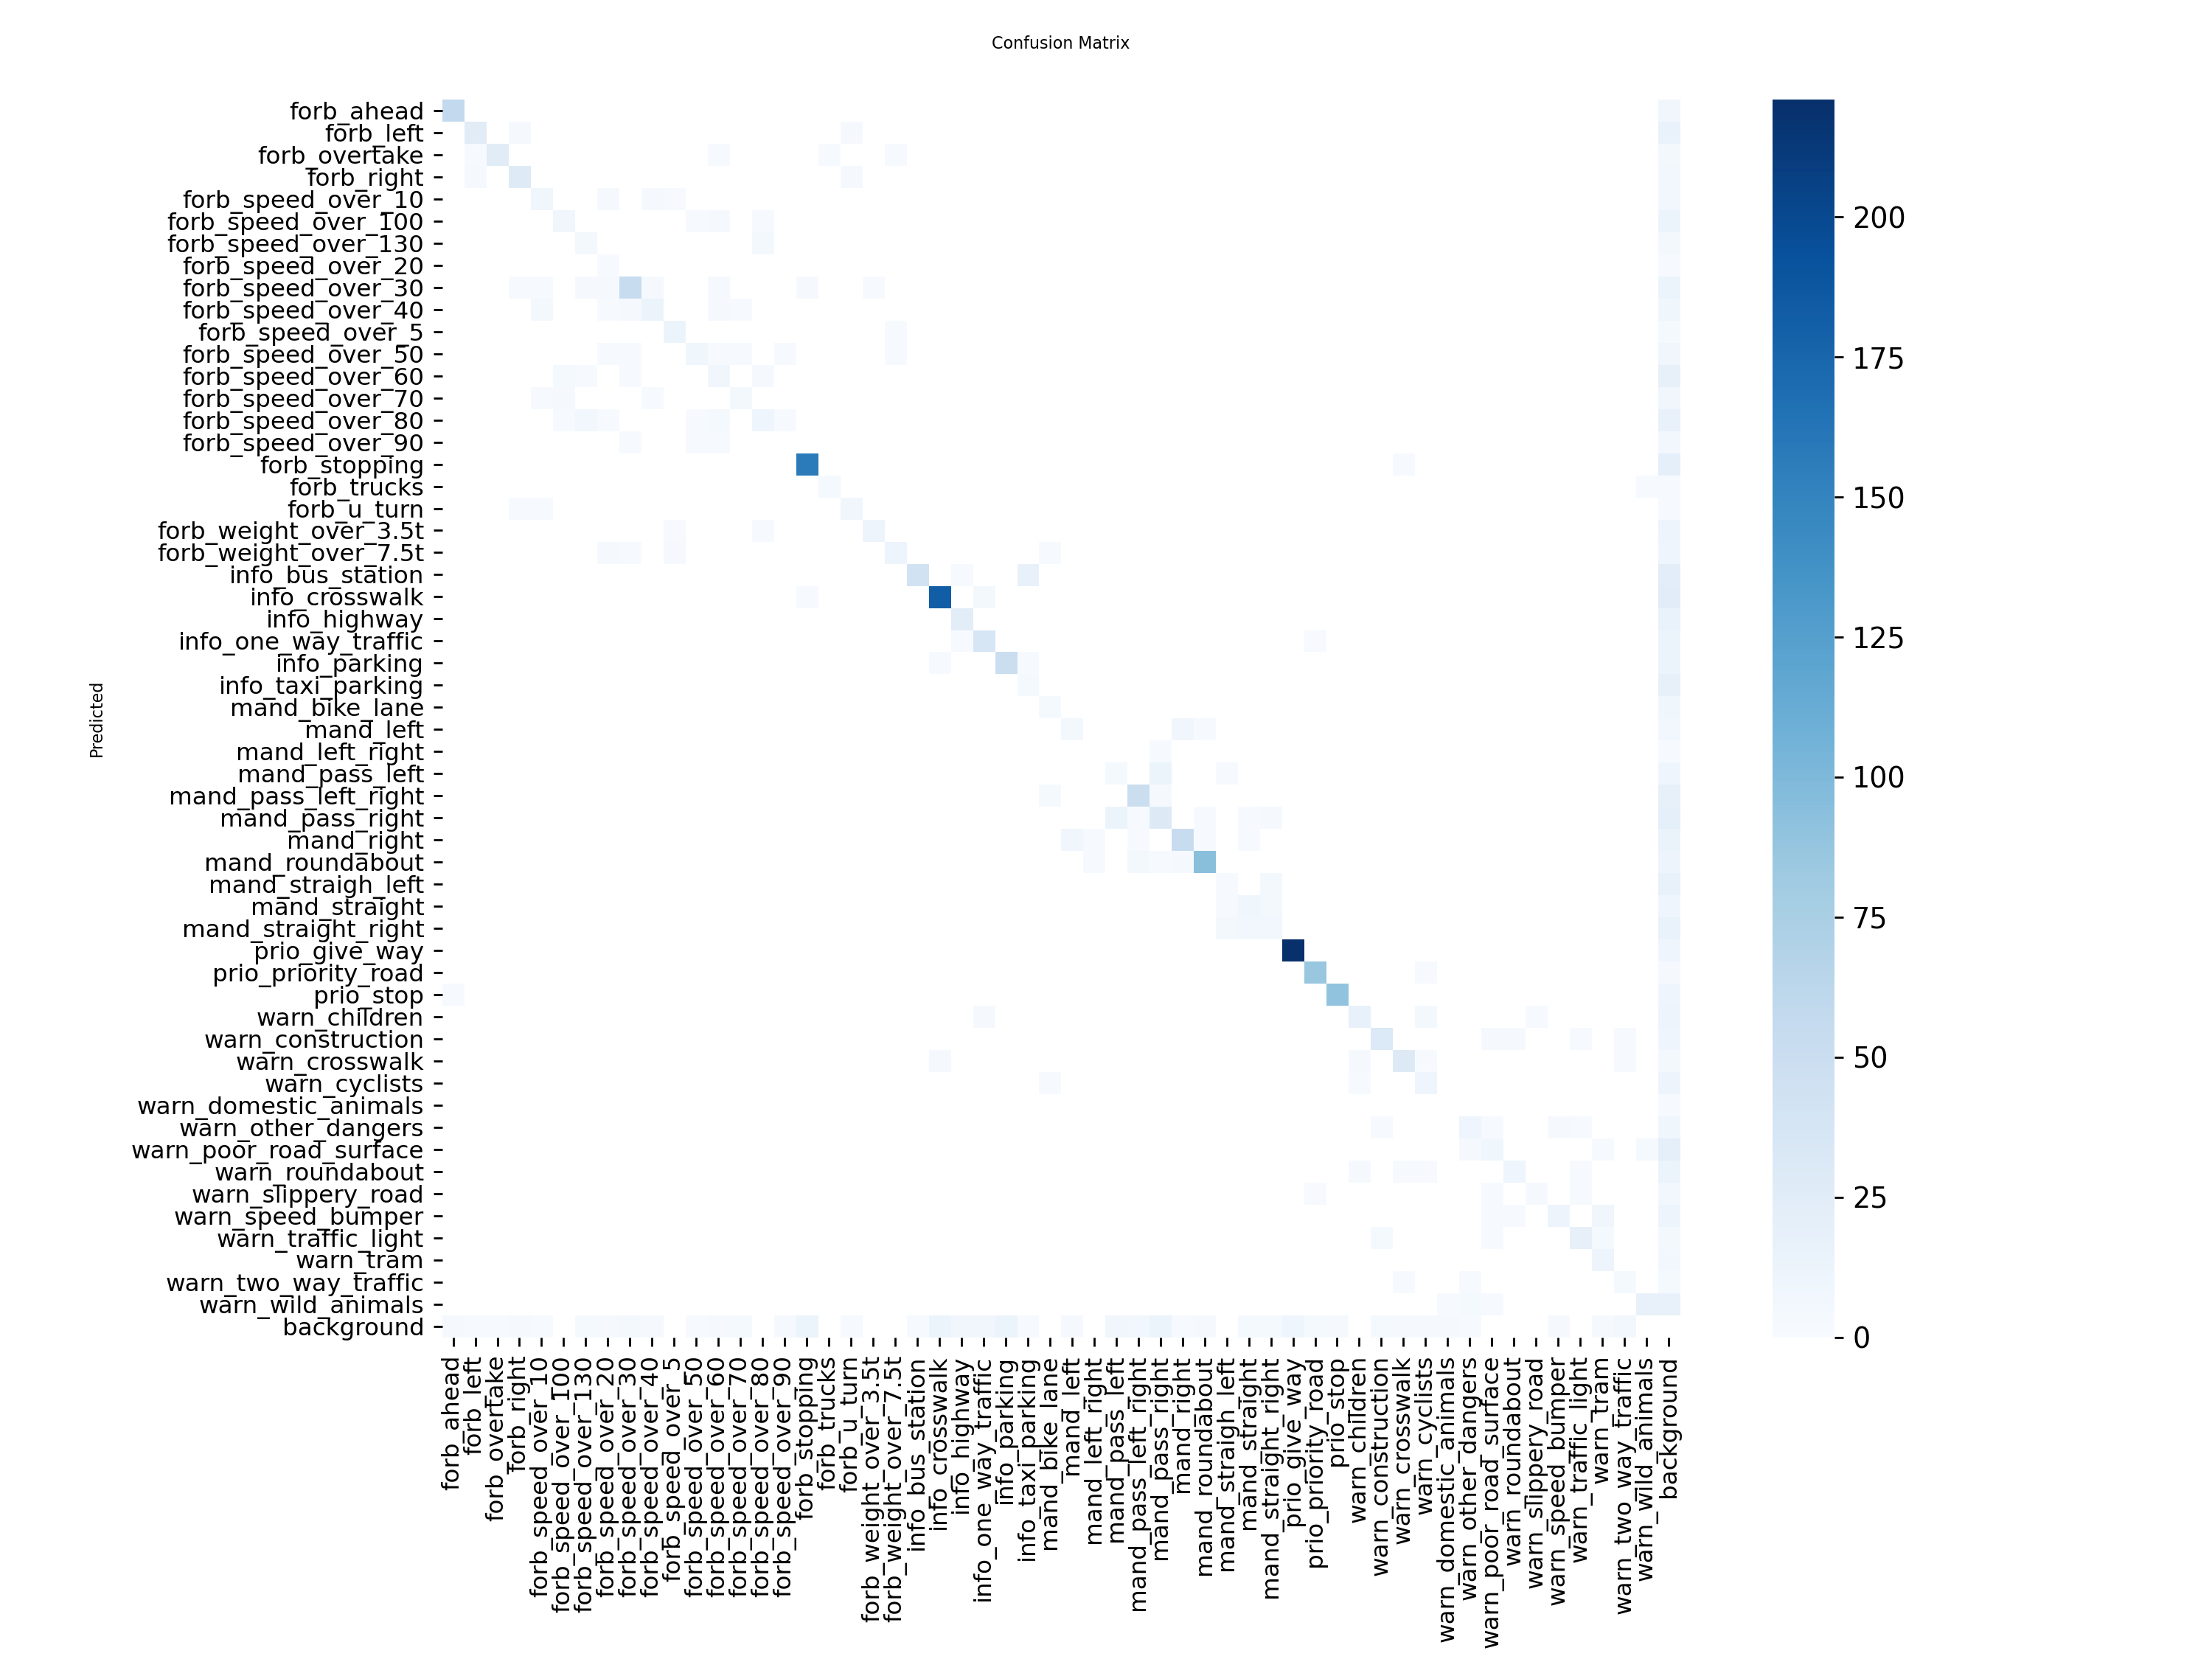


✅ Matriz de confusión (normalizada):


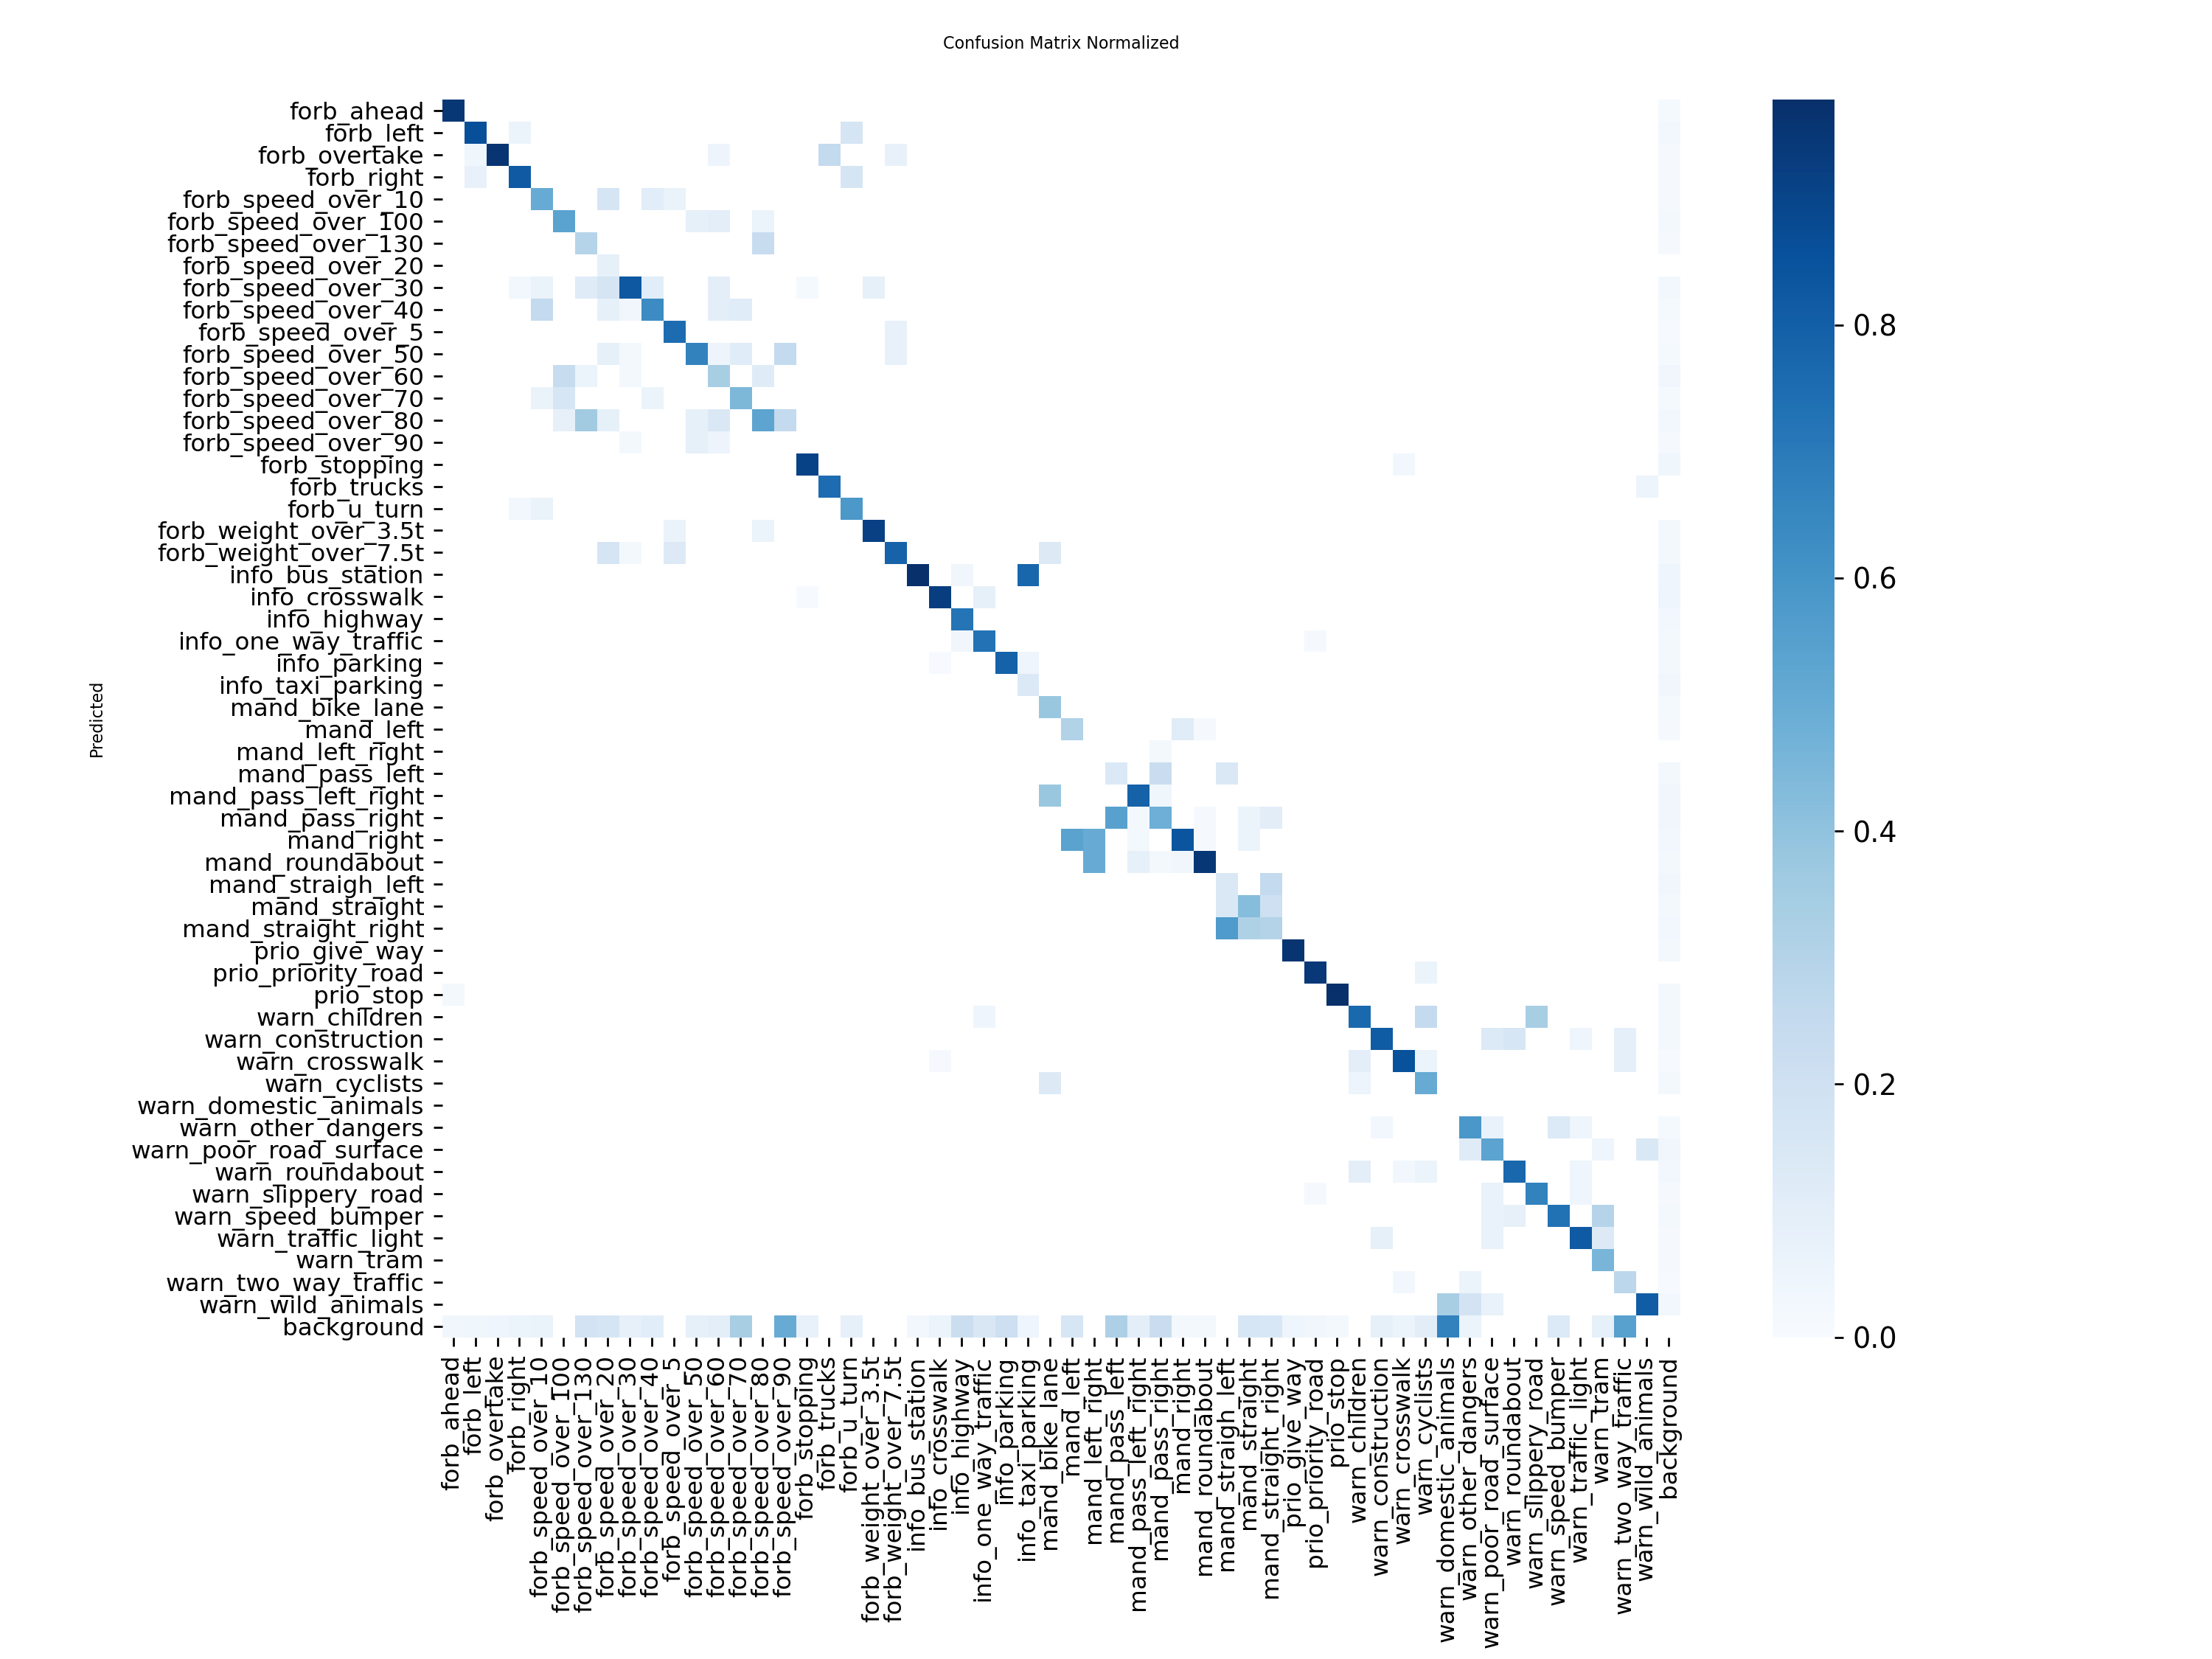

In [23]:
from IPython.display import Image, display
import os
import glob

print("="*70)
print("MÉTRICAS Y VISUALIZACIONES DEL ENTRENAMIENTO")
print("="*70)

# Buscar la carpeta del último entrenamiento
train_dirs = sorted([d for d in glob.glob("runs/detect/train*") if os.path.isdir(d)])
latest_train = train_dirs[-1] if train_dirs else None

if latest_train:
    print(f"\n✓ Carpeta: {latest_train}\n")
    
    # Mostrar archivos disponibles
    metricas = {
        'results.png': 'Gráficos de entrenamiento',
        'confusion_matrix.png': 'Matriz de confusión',
        'confusion_matrix_normalized.png': 'Matriz de confusión (normalizada)',
    }
    
    for archivo, descripcion in metricas.items():
        ruta_archivo = f"{latest_train}/{archivo}"
        if os.path.exists(ruta_archivo):
            print(f"✅ {descripcion}:")
            display(Image(filename=ruta_archivo))
            print()
        else:
            print(f"⚠️ {descripcion}: No encontrado")
else:
    print("❌ No se encontró la matriz en train6. Comprobando carpetas disponibles...")
    !ls runs/detect/